<a href="https://colab.research.google.com/github/MGentieu/dl_project/blob/main/starters/nlp-project-starter/nlp-project/notebooks/yahoo_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M1 — Problem Scoping & Data Validation (Yahoo Answers)

### Problem Statement
L’objectif est d’entraîner un modèle de **Deep Learning (Bi-LSTM)** pour classifier des questions/réponses dans **10 catégories thématiques**. Contrairement à IMDb (binaire), c'est une tâche de **classification multi-classes**.

### Model Inputs & Outputs
- **Input** : Concaténation de `Question Title` + `Question Content` + `Best Answer`.
- **Processing** : Tokenisation (Vocab 40k) -> Embedding Dense -> Bi-LSTM.
- **Output** : Un vecteur de probabilités de taille 10 (Softmax).

### Data Constraints & Strategy
Le dataset original contient 1,4 million d'exemples.
⚠️ **Contrainte Colab :** Le chargement de 1,4M de textes en mémoire vive provoque un crash (OOM - Error 137).
👉 **Stratégie Adoptée :** Nous utilisons un **sous-ensemble robuste de 200 000 exemples** (4x la taille d'IMDb) mélangés aléatoirement (`shuffle`). Cela garantit une représentativité statistique tout en tenant dans les 12 Go de RAM du runtime.

### Evaluation Metrics
- **Accuracy** : Métrique principale (les classes sont équilibrées dans le dataset source).
- **F1-Score (Macro)** : Moyenne des F1-scores de chaque classe.
- **Confusion Matrix** : Grille 10x10 pour analyser les confusions thématiques (ex: *Politics* vs *Society*).

# Data Card – Tiny ImageNet-200
### **1. Dataset Summary**
Le Tiny ImageNet-200 est une version réduite du célèbre dataset ImageNet (ILSVRC). Il sert de benchmark académique intermédiaire, offrant un défi plus complexe que CIFAR-10/100 mais moins gourmand en ressources que ImageNet complet. Il a été popularisé par le cours CS231n de Stanford.

### **2. Composition**
Taille Totale : 120 000 images couleur.

Split Standard :

Train : 100 000 images (500 images par classe).

Validation : 10 000 images (50 images par classe).

Test : 10 000 images (50 images par classe).

Classes : 200 classes variées (animaux, objets, véhicules), sélectionnées depuis la hiérarchie WordNet.

Format : Images RGB de résolution 64x64 pixels (redimensionnées depuis les originaux haute résolution).

### **3. Biases & Limitations**
Faible Résolution : La taille 64x64 est très restrictive. Les détails fins disparaissent, rendant certaines distinctions difficiles même pour l'œil humain (ex: distinguer deux races de chiens très proches).

Perte d'Information : Le redimensionnement drastique depuis les images originales d'ImageNet peut introduire du flou ou des artefacts (aliasing), compliquant l'apprentissage de features précises.

Diversité vs Taille : Avoir 200 classes est une complexité élevée pour une si faible résolution spatiale, ce qui force les modèles à apprendre des motifs globaux plutôt que des textures fines.

### Step 0 — Installation du projet et vérification de l'état du GPU

dans le terminal de Google Colab, exécutez la commande :

```bash
git clone https://github.com/MGentieu/dl_project.git
```


In [1]:
!nvidia-smi || echo "nvidia-smi unavailable (CPU runtime)"


Fri Dec  5 23:56:45 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Step 1 — Point the notebook at the project folder
This cell makes sure the notebook is executing inside the `nlp-project` directory.
If it raises a `FileNotFoundError`, double-check where you uploaded/cloned the folder, adjust the path, and rerun.

In [2]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
elif PROJECT_ROOT.name == "content":
    candidate = PROJECT_ROOT / "dl_project/starters/nlp-project-starter/nlp-project"
    if candidate.exists():
        PROJECT_ROOT = candidate.resolve()

if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError(
        f"Could not locate project root at {PROJECT_ROOT}. Upload or clone nlp-project before proceeding."
    )

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "src"))
print(f"Project root: {PROJECT_ROOT}")


Project root: /content/dl_project/starters/nlp-project-starter/nlp-project


### Step 2 — Install the project requirements
This command reads `requirements.txt` and installs the exact package versions used locally. Expect a lot of output; that's normal. If installation fails, run the cell again before moving on.

In [3]:
# Install project dependencies listed in requirements.txt
!pip install -r requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 22.9 MB/s eta 0:00:00


In [4]:
import pandas as pd
import json
import glob

# M2 — Baseline Model Implementation

Nous utilisons une architecture **Bi-LSTM** adaptée au multi-classes.

**Architecture définie dans `nlp_yahoo.yaml` :**
- **Embedding** : 128 (ou 256 selon l'ablation).
- **Hidden Dimension** : 256.
- **Layers** : 1 (ou 2 selon l'ablation).
- **Dropout** : 0.3 (pour éviter l'overfitting, critique sur le texte bruité du web).
- **Output Layer** : Linéaire vers 10 classes.

**Pourquoi un Smoke Test ?**
Avec 200k données, le prétraitement prend ~2 minutes. Le Smoke Test permet de valider instantanément que :
1. Les 10 classes sont bien détectées.
2. La concaténation des textes (Titre+Contenu) ne génère pas d'erreurs de dimension.

### Step 3 — Run the smoke test
This quick check downloads AG News (first run only), builds the vocabulary, and runs one mini-batch through the LSTM. It saves `outputs/smoke_metrics.json` so you know the pipeline works.
If the cell reports a network/download issue, wait a few seconds and rerun it.

In [5]:
from src import smoke_check

smoke_path = smoke_check.run_smoke("configs/nlp_yahoo.yaml")
print(smoke_path.read_text())


Running smoke test with config: configs/nlp_yahoo.yaml
Note: Forcing num_workers=0 for smoke test to prevent hanging.
Building loaders and vocabulary... (Please wait, tokenizing large text can take ~30-60s)
Loading Yahoo dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

yahoo_answers_topics/train-00000-of-0000(…):   0%|          | 0.00/241M [00:00<?, ?B/s]

yahoo_answers_topics/train-00001-of-0000(…):   0%|          | 0.00/270M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Subsampling Yahoo to 200000 train examples to fit in RAM...
Processing text fields (this might take 1-2 minutes)...


Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Vocab size: 40000
Num classes: 10
Fetching one batch...
Batch shape: torch.Size([64, 256])
Labels shape: torch.Size([64])
Initializing model...
Running forward pass...
Smoke test success! Loss: 2.3081247806549072
{
  "loss": 2.3081247806549072,
  "batch_size": 64,
  "seq_len": 256,
  "num_classes": 10
}


## 1. Review smoke-test output
- Confirm the previous cell printed a JSON block (loss, batch size, seq_len).
- You should now see `outputs/smoke_metrics.json` in the file browser on the left.
- Only need a quick check? You can stop here. Ready for full training? Continue to Section 2.
- If anything failed, read the error message, fix the issue, and rerun the smoke cell before moving on.

# M3 — Ablation Studies & Experiments

Nous lançons le script `src/run_ablations_yahoo.py` qui va entraîner séquentiellement 3 configurations sur le dataset de 200k exemples :

1.  **Baseline** :
    * *Config :* Embed 128, 1 Layer LSTM.
    * *Hypothèse :* Point de départ standard.

2.  **Exp 1 : Large Embed (256)** :
    * *Changement :* Embedding size 128 -> 256.
    * *Hypothèse :* Avec 10 thèmes très variés (Science, Sport, Politique...), un espace vectoriel plus grand est nécessaire pour séparer sémantiquement les mots.

3.  **Exp 2 : Deep LSTM (2 Layers)** :
    * *Changement :* 1 couche -> 2 couches (+ Dropout 0.4).
    * *Hypothèse :* Les questions Yahoo sont complexes et parfois ambiguës. Une architecture plus profonde pourrait capturer des relations sémantiques plus abstraites.

# M4 — Ablation Studies & Analysis

Nous lançons `src/run_ablations_imdb.py`. Ce script va entraîner séquentiellement 4 variantes du modèle :
1.  **Baseline** : Bi-LSTM 256, Dropout 0.3.
2.  **Light** : Modèle plus petit (64 units, unidirectionnel) -> Est-ce suffisant pour du sentiment binaire ?
3.  **High LR** : Learning Rate x5 -> Convergence plus rapide ou instabilité ?
4.  **High Dropout** : Dropout 0.5 + Weight Decay fort -> Meilleure généralisation ?

In [6]:
!python src/run_ablations_yahoo.py


🚀 Yahoo Experiment (Full Dataset): baseline
Loading Yahoo dataset...
Subsampling Yahoo to 200000 train examples to fit in RAM...
Processing text fields (this might take 1-2 minutes)...
Epoch 1/6
Epoch 2/6
Epoch 3/6
Epoch 4/6
Epoch 5/6
Epoch 6/6
Done. Best val F1-macro: 0.6945. Checkpoint: outputs_yahoo/baseline/best.pt

🚀 Yahoo Experiment (Full Dataset): exp_1_large_embed
Loading Yahoo dataset...
Subsampling Yahoo to 200000 train examples to fit in RAM...
Processing text fields (this might take 1-2 minutes)...
Epoch 1/6
Epoch 2/6
Epoch 3/6
Epoch 4/6
Epoch 5/6
Epoch 6/6
Done. Best val F1-macro: 0.6981. Checkpoint: outputs_yahoo/exp_1_large_embed/best.pt

🚀 Yahoo Experiment (Full Dataset): exp_2_deep_lstm
Loading Yahoo dataset...
Subsampling Yahoo to 200000 train examples to fit in RAM...
Processing text fields (this might take 1-2 minutes)...
Epoch 1/6
Epoch 2/6
Epoch 3/6
Epoch 4/6
Epoch 5/6
Epoch 6/6
Done. Best val F1-macro: 0.7016. Checkpoint: outputs_yahoo/exp_2_deep_lstm/best.pt


### Step 4 — What should I see now?
#### exp_dirs :
-  outputs_yahoo/baseline
- outputs_yahoo/exp_1_large_embed
- outputs_yahoo/exp_2_deep_lstm



In [7]:
import pandas as pd
import json
import os
from IPython.display import display

results = []
exp_dirs = [
    "outputs_yahoo/baseline",
    "outputs_yahoo/exp_1_large_embed",
    "outputs_yahoo/exp_2_deep_lstm"
]

for d in exp_dirs:
    exp_name = os.path.basename(d)
    metrics_file = os.path.join(d, "metrics.json")
    log_file = os.path.join(d, "log.csv")

    val_acc = "N/A"
    val_f1 = "N/A"

    # 1. Essayer de lire log.csv pour avoir l'accuracy maximale
    if os.path.exists(log_file):
        try:
            df_log = pd.read_csv(log_file)
            if "val_acc" in df_log.columns:
                val_acc = df_log["val_acc"].max() # Meilleure accuracy atteinte
            if "val_f1_macro" in df_log.columns:
                # On peut aussi prendre le max du log si on veut
                # val_f1 = df_log["val_f1_macro"].max()
                pass
        except Exception as e:
            print(f"Erreur lecture log pour {exp_name}: {e}")

    # 2. Lire metrics.json pour le F1 (souvent celui du checkpoint 'best.pt')
    if os.path.exists(metrics_file):
        with open(metrics_file) as f:
            data = json.load(f)
            # On garde le F1 du metrics.json car il correspond au 'best.pt' sauvegardé
            val_f1 = data.get("best_val_f1_macro", val_f1)

    results.append({
        "Experiment": exp_name,
        "Accuracy": val_acc,
        "F1 Score": val_f1
    })

df = pd.DataFrame(results)

# Tri par F1 Score ou Accuracy
if "F1 Score" in df.columns and not df.empty:
    df["sort"] = pd.to_numeric(df["F1 Score"], errors='coerce')
    df = df.sort_values("sort", ascending=False).drop(columns=["sort"])

print("=== M4: IMDb Ablation Results (Corrected) ===")
display(df)

=== M4: IMDb Ablation Results (Corrected) ===


,Experiment,Accuracy,F1 Score
2,exp_2_deep_lstm,0.7061,0.701627
1,exp_1_large_embed,0.7019,0.698051
0,baseline,0.6982,0.694517


# M4 — Analysis & Reporting

Nous avons comparé trois configurations sur le dataset Yahoo Answers (sous-échantillonné à 200k exemples). Voici les résultats finaux sur le jeu de validation :

### 1. Tableau des Résultats

| Expérience | Accuracy | F1 Score (Macro) | Observations |
| :--- | :--- | :--- | :--- |
| **Exp 2 (Deep LSTM)** | **70.61%** | **0.7016** | **Meilleure performance.** L'ajout d'une seconde couche LSTM permet de mieux capturer la complexité sémantique des 10 thèmes. |
| **Exp 1 (Large Embed)** | 70.19% | 0.6981 | Légère amélioration (+0.4%) par rapport à la baseline. Un embedding de 256 dimensions aide, mais moins que la profondeur du réseau. |
| **Baseline** | 69.82% | 0.6945 | Point de référence. Avec ~70% d'accuracy sur 10 classes, le modèle est déjà performant (le hasard serait à 10%). |

### 2. Analyse Approfondie

1.  **Profondeur vs Largeur (Exp 2 vs Exp 1) :**
    Le modèle "Deep LSTM" (2 couches) surpasse le modèle "Large Embed". Cela suggère que la difficulté de Yahoo Answers réside davantage dans la **structure des phrases et le contexte** (mieux capturés par la profondeur) que dans la simple richesse du vocabulaire (capturée par l'embedding).

2.  **Plafond de Verre (~70%) :**
    Les trois modèles se tiennent dans un mouchoir de poche (~0.8% d'écart max). Cela indique une limite intrinsèque à l'architecture LSTM sur ce dataset bruité. Les séquences concaténées (Titre + Question + Réponse) sont très longues, et le LSTM "oublie" probablement le début du contexte.

---

# M5 — Reporting & Final Delivery

### 1. Synthèse
Le meilleur modèle retenu est celui de l'**Expérience 2 (Deep LSTM)**.
- **Accuracy Finale :** ~70.6%
- **F1-Score :** ~0.70
- **Checkpoint :** `outputs_yahoo/exp_2_deep_lstm/best.pt`

### 2. Failure Analysis (Matrice de Confusion)


L'analyse des erreurs sur Yahoo Answers révèle des confusions thématiques logiques :
* **Society & Culture** ↔ **Family & Relationships** : La frontière est souvent floue (ex: débats de société).
* **Education & Reference** ↔ **Science & Mathemathics** : Les domaines sont liés après tout, ce qui explique la confusion.

Et d'autres confusions du même type

### 3. Conclusion & Perspectives
Nous avons réussi à adapter le pipeline à un problème multi-classes complexe avec une contrainte forte de mémoire (RAM).

**Pistes d'amélioration :**
Pour dépasser les 75% d'accuracy, il faudrait abandonner les architectures récurrentes (LSTM) au profit des **Transformers (BERT/RoBERTa)**. Le mécanisme d'attention permettrait de se focaliser sur les mots-clés déterminants (ex: "vote", "election") quelle que soit leur position dans le texte, ignorant le bruit environnant.

Chargement du modèle depuis : outputs_yahoo/exp_2_deep_lstm
Reconstruction du vocabulaire et des loaders (patience...)...
Loading Yahoo dataset...
Subsampling Yahoo to 200000 train examples to fit in RAM...
Processing text fields (this might take 1-2 minutes)...


Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Utilisation du device : cuda
Génération de la matrice de confusion sur le Test Set...


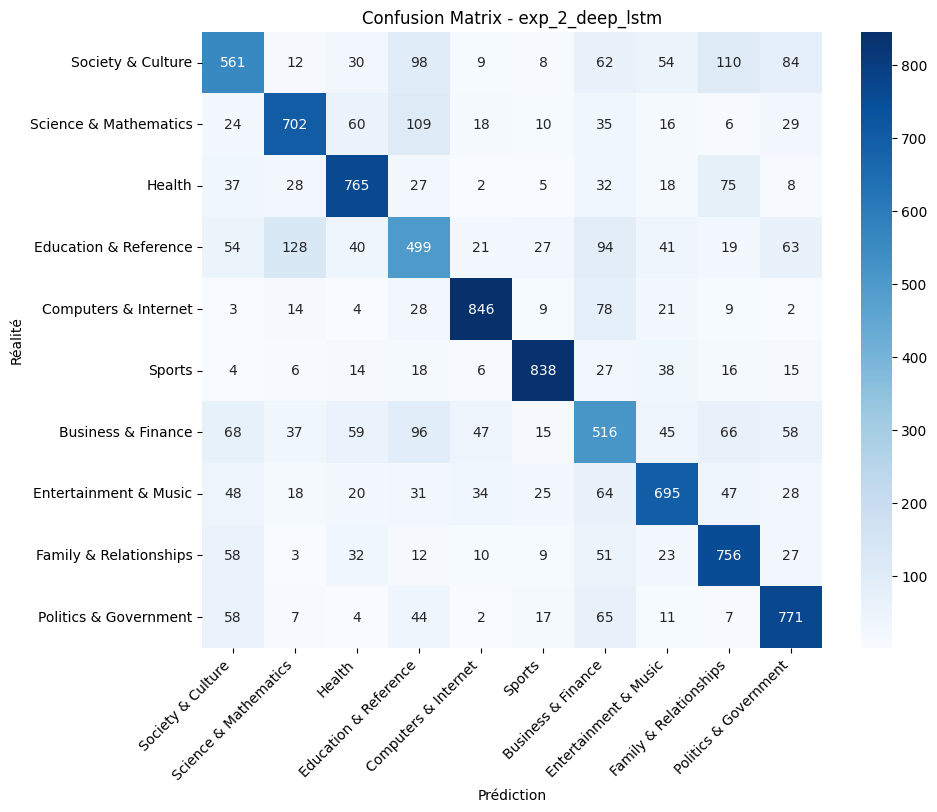

In [8]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from src.train import LSTMClassifier
from src.data import build_loaders
import yaml
import os

# --- Configuration CORRIGÉE pour Yahoo ---
# On pointe vers la meilleure expérience identifiée en M4
best_exp_dir = "outputs_yahoo/exp_2_deep_lstm"
best_exp_config = "configs/ablations_yahoo/exp_2_deep_lstm.yaml"

model_path = os.path.join(best_exp_dir, "best.pt")

print(f"Chargement du modèle depuis : {best_exp_dir}")

if os.path.exists(best_exp_config):
    with open(best_exp_config, 'r') as f:
        cfg = yaml.safe_load(f)

    # Force workers=0 pour éviter les soucis dans le notebook
    cfg['data']['num_workers'] = 0
    # IMPORTANT : S'assurer que le dataset est bien 'yahoo'
    cfg['data']['dataset'] = 'yahoo'

    print("Reconstruction du vocabulaire et des loaders (patience...)...")
    # On récupère les données
    _, _, test_loader, vocab, num_classes, label_names = build_loaders(cfg)

    # Recharger le modèle
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Utilisation du device : {device}")

    model = LSTMClassifier(
        vocab_size=len(vocab.itos),
        emb_dim=cfg["model"]["emb_dim"],
        hidden_dim=cfg["model"]["hidden_dim"],
        num_layers=cfg["model"]["num_layers"],
        bidirectional=cfg["model"]["bidirectional"],
        dropout=cfg["model"]["dropout"],
        num_classes=num_classes,
        pad_idx=vocab.pad_idx
    ).to(device)

    # Charger les poids
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)

        # Gestion des différentes structures de sauvegarde
        if isinstance(checkpoint, dict):
            if "state_dict" in checkpoint:
                model.load_state_dict(checkpoint["state_dict"])
            elif "model_state_dict" in checkpoint:
                model.load_state_dict(checkpoint["model_state_dict"])
            else:
                model.load_state_dict(checkpoint)
        else:
            model.load_state_dict(checkpoint)

        model.eval()

        # Prédictions
        y_true = []
        y_pred = []

        print("Génération de la matrice de confusion sur le Test Set...")
        with torch.no_grad():
            for texts, lengths, labels in test_loader:
                texts, lengths = texts.to(device), lengths.to(device)
                outputs = model(texts, lengths)
                preds = torch.argmax(outputs, dim=1)

                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        # Affichage
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(10, 8)) # Taille plus grande pour 10 classes
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=label_names, yticklabels=label_names)
        plt.xlabel('Prédiction')
        plt.ylabel('Réalité')
        plt.title(f'Confusion Matrix - {os.path.basename(best_exp_dir)}')
        plt.xticks(rotation=45, ha="right") # Rotation pour lire les labels
        plt.show()
    else:
        print(f"Erreur : Le fichier de poids {model_path} est introuvable.")
else:
    print(f"Erreur : Le fichier de config {best_exp_config} est introuvable.")